# H2O Polarizability and Raman Intensity with Power-Series Fits

This notebook loads a single `freq_dev` run with Gecko and plots raw data + fits using

`f(omega) = f(0) * [1 + A*omega^2 + B*omega^4 + C*omega^6]`

for frequency-dependent terms in polarizability and Raman `pol_int`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gecko import fallback for local dev environments
try:
    import gecko
except ImportError:
    gecko_src = Path('/gpfs/projects/rjh/adrian/development/gecko/src')
    if gecko_src.exists():
        sys.path.insert(0, str(gecko_src))
    import gecko

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
})


def fit_even_power_series(omega, y, max_power=6, eps=1e-12):
    omega = np.asarray(omega, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    mask = np.isfinite(omega) & np.isfinite(y)
    if np.count_nonzero(mask) < 2:
        return {'ok': False, 'reason': 'not_enough_points'}

    om = omega[mask]
    yy = y[mask]
    order = np.argsort(om)
    om = om[order]
    yy = yy[order]

    # Keep one value per frequency (mean if duplicated)
    uniq, inv = np.unique(om, return_inverse=True)
    if uniq.size != om.size:
        yy_agg = np.zeros_like(uniq)
        counts = np.zeros_like(uniq)
        for i, g in enumerate(inv):
            yy_agg[g] += yy[i]
            counts[g] += 1.0
        yy = yy_agg / np.maximum(counts, 1.0)
        om = uniq

    powers_all = [p for p in range(2, max_power + 1, 2)]
    has_zero = np.any(np.isclose(om, 0.0, atol=1e-12))

    # Prefer constrained fit anchored to observed f(0)
    if has_zero:
        f0 = float(np.mean(yy[np.isclose(om, 0.0, atol=1e-12)]))
    else:
        f0 = np.nan

    if has_zero and np.isfinite(f0) and abs(f0) > eps:
        n_terms = min(len(powers_all), max(1, om.size - 1))
        powers = powers_all[:n_terms]
        X = np.column_stack([om ** p for p in powers])
        target = yy / f0 - 1.0
        coeff, *_ = np.linalg.lstsq(X, target, rcond=None)
        y_fit = f0 * (1.0 + X @ coeff)
        model = 'anchored_f0'
        rel_coeff = {p: float(c) for p, c in zip(powers, coeff)}
        abs_coeff = {0: float(f0)}
        for p, c in zip(powers, coeff):
            abs_coeff[p] = float(f0 * c)
    else:
        n_params = min(om.size, 1 + len(powers_all))
        powers = powers_all[:max(0, n_params - 1)]
        Xcols = [np.ones_like(om)] + [om ** p for p in powers]
        X = np.column_stack(Xcols)
        coeff, *_ = np.linalg.lstsq(X, yy, rcond=None)
        y_fit = X @ coeff
        f0 = float(coeff[0])
        model = 'free_c0'
        abs_coeff = {0: float(coeff[0])}
        for p, c in zip(powers, coeff[1:]):
            abs_coeff[p] = float(c)
        rel_coeff = {}
        if abs(f0) > eps:
            for p, c in zip(powers, coeff[1:]):
                rel_coeff[p] = float(c / f0)

    ss_res = float(np.sum((yy - y_fit) ** 2))
    ss_tot = float(np.sum((yy - np.mean(yy)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > eps else np.nan

    return {
        'ok': True,
        'model': model,
        'omega': om,
        'y': yy,
        'y_fit': y_fit,
        'f0': f0,
        'powers': powers,
        'rel_coeff': rel_coeff,  # A, B, C map by power 2,4,6
        'abs_coeff': abs_coeff,
        'r2': r2,
    }


def eval_fit(omega, fit):
    om = np.asarray(omega, dtype=float)
    if not fit.get('ok', False):
        return np.full_like(om, np.nan, dtype=float)

    if fit['model'] == 'anchored_f0':
        out = np.ones_like(om, dtype=float)
        for p in fit['powers']:
            out += fit['rel_coeff'].get(p, 0.0) * (om ** p)
        return fit['f0'] * out

    out = np.full_like(om, fit['abs_coeff'].get(0, 0.0), dtype=float)
    for p in fit['powers']:
        out += fit['abs_coeff'].get(p, 0.0) * (om ** p)
    return out


In [2]:
# Update this path if you want to analyze a different run
RUN_ROOT = Path('/gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto')
calc = gecko.load_calc(RUN_ROOT)
print('Loaded:', RUN_ROOT)
print('Available keys:', sorted(calc.data.keys()))


Loaded: /gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.350-nauto
Available keys: ['alpha', 'beta', 'excited_states', 'hessian', 'input_molecule', 'molecule', 'normal_modes', 'orbital_energies', 'output_molecule', 'polarization_frequencies', 'raman', 'raw_json', 'timings', 'vibrational_frequencies']


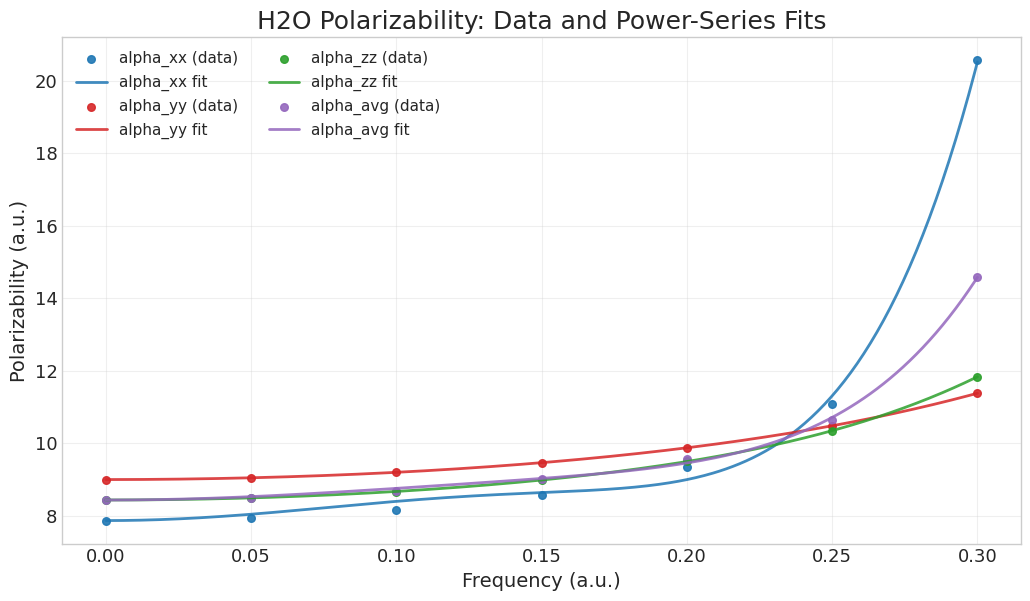

Polarizability fit coefficients


,term,model,f0,A (w^2),B (w^4),C (w^6),R2
0,alpha_xx,anchored_f0,7.862755,9.751435,-349.289337,4886.435177,0.997977
1,alpha_yy,anchored_f0,8.995132,2.168536,5.201732,38.031519,0.999999
2,alpha_zz,anchored_f0,8.430817,2.764388,2.068371,189.505885,0.999990
3,alpha_avg,anchored_f0,8.429568,4.724855,-106.061117,1595.994449,0.998987


Polarizability values vs fit at sampled frequencies


,omega,alpha_xx_data,alpha_xx_fit,alpha_yy_data,alpha_yy_fit,alpha_zz_data,alpha_zz_fit,alpha_avg_data,alpha_avg_fit
0,0.00,7.862755,7.862755,8.995132,8.995132,8.430817,8.430817,8.429568,8.429568
1,0.05,7.930006,8.037873,9.042983,9.044195,8.487342,8.489216,8.486777,8.523762
2,0.10,8.146159,8.393270,9.193842,9.195216,8.662415,8.667219,8.667472,8.751901
3,0.15,8.566867,8.635185,9.462297,9.461607,8.981082,8.982230,9.003415,9.026341
4,0.20,9.348741,8.994412,9.872846,9.872141,9.499791,9.493212,9.573792,9.453255
5,0.25,11.083689,11.306882,10.479933,10.480568,10.341456,10.345623,10.635026,10.711025
6,0.30,20.571532,20.526483,11.379229,11.379087,11.835168,11.834325,14.595309,14.579965


In [3]:
# Polarizability vs frequency with power-series fits
alpha = calc.data.get('alpha', {})
omega = np.asarray(alpha.get('omega', []), dtype=float).reshape(-1)
components = [str(c).lower() for c in alpha.get('components', [])]
values = np.asarray(alpha.get('values', []), dtype=float)

if values.ndim == 1:
    if len(components) > 0 and values.size % len(components) == 0:
        values = values.reshape(-1, len(components))
    elif omega.size > 0 and values.size % omega.size == 0:
        values = values.reshape(omega.size, -1)
    else:
        raise RuntimeError('Could not reshape alpha values')

if values.shape[0] != omega.size:
    if values.ndim == 2 and values.shape[1] == omega.size:
        values = values.T
    else:
        raise RuntimeError('Alpha values/frequency axis mismatch')

if len(components) == values.shape[1] and all(c in components for c in ('xx', 'yy', 'zz')):
    c2i = {c: i for i, c in enumerate(components)}
    axx = values[:, c2i['xx']]
    ayy = values[:, c2i['yy']]
    azz = values[:, c2i['zz']]
elif values.shape[1] >= 9:
    axx, ayy, azz = values[:, 0], values[:, 4], values[:, 8]
else:
    raise RuntimeError('Could not locate xx/yy/zz components')

alpha_terms = {
    'alpha_xx': axx,
    'alpha_yy': ayy,
    'alpha_zz': azz,
}
alpha_terms['alpha_avg'] = (alpha_terms['alpha_xx'] + alpha_terms['alpha_yy'] + alpha_terms['alpha_zz']) / 3.0

term_colors = {
    'alpha_xx': '#1f77b4',
    'alpha_yy': '#d62728',
    'alpha_zz': '#2ca02c',
    'alpha_avg': '#9467bd',
}

fit_results = {name: fit_even_power_series(omega, y, max_power=6) for name, y in alpha_terms.items()}

fig, ax = plt.subplots(figsize=(10.5, 6.2))
omega_line = np.linspace(float(np.nanmin(omega)), float(np.nanmax(omega)), 400)

for name, y in alpha_terms.items():
    color = term_colors[name]
    ax.scatter(omega, y, s=30, alpha=0.9, color=color, label=f'{name} (data)')
    fit = fit_results[name]
    if fit.get('ok', False):
        y_line = eval_fit(omega_line, fit)
        ax.plot(omega_line, y_line, lw=2.0, color=color, alpha=0.85, label=f'{name} fit')

ax.set_xlabel('Frequency (a.u.)')
ax.set_ylabel('Polarizability (a.u.)')
ax.set_title('H2O Polarizability: Data and Power-Series Fits')
ax.grid(alpha=0.30)
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

# Coefficients table: f(w)=f0*[1 + A*w^2 + B*w^4 + C*w^6]
coef_rows = []
for name, fit in fit_results.items():
    row = {
        'term': name,
        'model': fit.get('model'),
        'f0': fit.get('f0', np.nan),
        'A (w^2)': fit.get('rel_coeff', {}).get(2, np.nan),
        'B (w^4)': fit.get('rel_coeff', {}).get(4, np.nan),
        'C (w^6)': fit.get('rel_coeff', {}).get(6, np.nan),
        'R2': fit.get('r2', np.nan),
    }
    coef_rows.append(row)

coef_df = pd.DataFrame(coef_rows)
print('Polarizability fit coefficients')
display(coef_df)

# Values table: raw + fit at sampled frequencies
value_df = pd.DataFrame({'omega': omega})
for name, y in alpha_terms.items():
    value_df[f'{name}_data'] = y
    value_df[f'{name}_fit'] = eval_fit(omega, fit_results[name])

print('Polarizability values vs fit at sampled frequencies')
display(value_df)


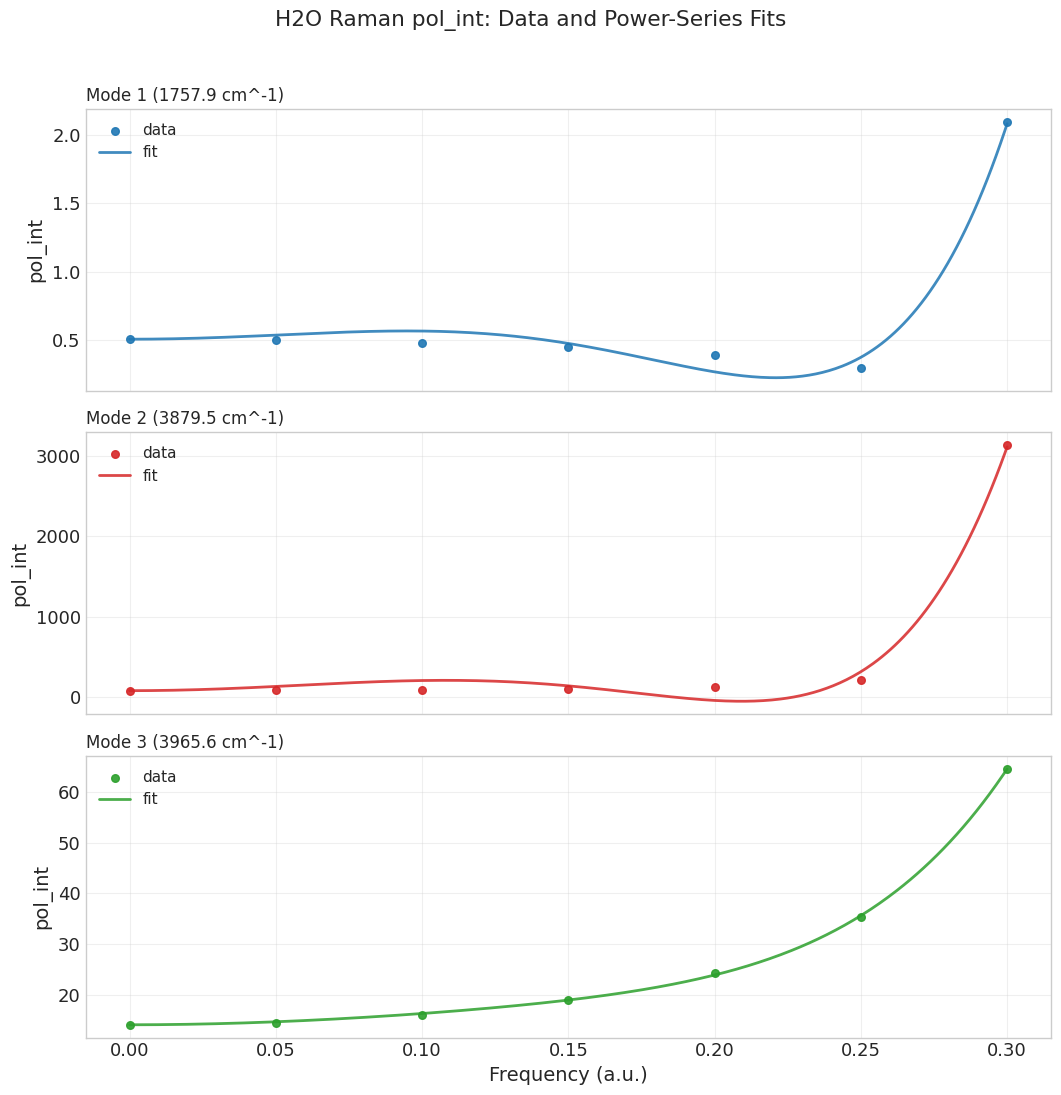

Raman pol_int fit coefficients


,mode,freq_cm1,model,f0,A (w^2),B (w^4),C (w^6),R2
0,1,1757.944750,anchored_f0,0.507162,28.156503,-1853.111821,21373.064269,0.987197
1,2,3879.459295,anchored_f0,80.758001,298.560651,-16179.858608,194387.816478,0.992366
2,3,3965.600075,anchored_f0,14.218876,16.949702,-187.670644,4839.588582,0.999863


Raman pol_int values vs fit at sampled frequencies


,omega,mode1_data,mode1_fit,mode2_data,mode2_fit,mode3_data,mode3_fit
0,0.00,0.507162,0.507162,80.758001,80.758001,14.218876,14.218876
1,0.05,0.502401,0.537157,82.922913,133.114611,14.657915,14.805788
2,0.10,0.479775,0.566818,90.004671,206.902683,16.201323,16.430900
3,0.15,0.452900,0.476142,104.109635,140.580295,18.992139,19.074423
4,0.20,0.391124,0.268369,132.234818,-40.744630,24.362109,23.993624
5,0.25,0.297476,0.374842,207.942755,316.202383,35.427817,35.658213
6,0.30,2.097438,2.081822,3132.786829,3110.985739,64.506281,64.459868


In [4]:
# Raman polarizability intensity (pol_int) vs frequency with power-series fits
raman = calc.data.get('raman', {})
rbf = raman.get('raman_by_freq', {})
if not isinstance(rbf, dict) or len(rbf) == 0:
    raise RuntimeError('No raman_by_freq data found')

freqs = np.array(sorted(float(k) for k in rbf.keys()), dtype=float)
mode_to_pol = {1: [], 2: [], 3: []}
mode_to_freqcm = {}

for f in freqs:
    entries = rbf.get(float(f), rbf.get(str(f), []))
    if not isinstance(entries, list):
        continue
    by_mode = {
        int(e.get('mode')): e
        for e in entries
        if isinstance(e, dict) and e.get('mode') is not None
    }
    for mode in (1, 2, 3):
        e = by_mode.get(mode, {})
        mode_to_pol[mode].append(float(e.get('pol_int', np.nan)))
        if mode not in mode_to_freqcm and 'freq_cm1' in e:
            mode_to_freqcm[mode] = float(e['freq_cm1'])

mode_fit = {mode: fit_even_power_series(freqs, mode_to_pol[mode], max_power=6) for mode in (1, 2, 3)}

fig, axes = plt.subplots(3, 1, figsize=(10.8, 11.0), sharex=True)
colors = ['#1f77b4', '#d62728', '#2ca02c']
omega_line = np.linspace(float(np.nanmin(freqs)), float(np.nanmax(freqs)), 400)

for i, mode in enumerate((1, 2, 3)):
    y = np.asarray(mode_to_pol[mode], dtype=float)
    fit = mode_fit[mode]

    label = f'Mode {mode}'
    if mode in mode_to_freqcm and np.isfinite(mode_to_freqcm[mode]):
        label += f' ({mode_to_freqcm[mode]:.1f} cm^-1)'

    axes[i].scatter(freqs, y, s=30, color=colors[i], alpha=0.9, label='data')
    if fit.get('ok', False):
        y_line = eval_fit(omega_line, fit)
        axes[i].plot(omega_line, y_line, lw=2.0, color=colors[i], alpha=0.85, label='fit')

    axes[i].set_ylabel('pol_int')
    axes[i].set_title(label, loc='left', fontsize=12)
    axes[i].grid(alpha=0.30)
    axes[i].legend(loc='best')

axes[-1].set_xlabel('Frequency (a.u.)')
fig.suptitle('H2O Raman pol_int: Data and Power-Series Fits', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Coefficients table
rows = []
for mode in (1, 2, 3):
    fit = mode_fit[mode]
    rows.append({
        'mode': mode,
        'freq_cm1': mode_to_freqcm.get(mode, np.nan),
        'model': fit.get('model'),
        'f0': fit.get('f0', np.nan),
        'A (w^2)': fit.get('rel_coeff', {}).get(2, np.nan),
        'B (w^4)': fit.get('rel_coeff', {}).get(4, np.nan),
        'C (w^6)': fit.get('rel_coeff', {}).get(6, np.nan),
        'R2': fit.get('r2', np.nan),
    })

raman_coef_df = pd.DataFrame(rows)
print('Raman pol_int fit coefficients')
display(raman_coef_df)

# Values table: raw + fit at sampled frequencies
raman_values_df = pd.DataFrame({'omega': freqs})
for mode in (1, 2, 3):
    y = np.asarray(mode_to_pol[mode], dtype=float)
    raman_values_df[f'mode{mode}_data'] = y
    raman_values_df[f'mode{mode}_fit'] = eval_fit(freqs, mode_fit[mode])

print('Raman pol_int values vs fit at sampled frequencies')
display(raman_values_df)
